## Classification Tree

In this part we classify the deposits with a single classification tree, pruned by cost-complexity pruning as the regression trees of `1B1_pruned_cart`. A classification tree splits the deposits into groups as pure as possible in label, and gives readable rules on what makes a deposit non-conforming. The deposits, their inputs and their label are those of the naive Bayes notebook (`deposit_data`).

### Main observations

- **Full tree:** 30 leaves, a train F1 of 1 and a validation F1 of 0.71: it learns the training deposits by heart.
- **Pruning:** The best pruned tree has 23 leaves (F1 of 0.72), and the one standard error rule keeps 11 leaves for 0.71. Below 10 leaves the F1 falls (0.63 with 4 leaves).
- **Readable rules:** The 11-leaf tree splits first on sulphur: the 23 deposits with more than 0.013% S, mostly the submerged arc deposits of two papers, are all non-conforming. It then splits on the heat treatment: the deposits never stress relieved (only the 250 °C hydrogen removal treatment) are mostly conforming (13 non-conforming out of 64), the deposits stress relieved at 580 °C are non-conforming in about half of the cases, on the yield strength and the UTS, unless they have more than 1.3% Mn.
- **Results:** F1 of 0.72 and recall of 0.71 (nested F1 of 0.70), below the four pruned regression trees of `1B1` and their thresholds (0.77 and 0.81). For a single tree, going through the regressions is better: each regression tree learns from 558 to 723 rows, the classification tree from 175 deposits.

### Operations in order

1. Load the train set with `load_train` and the labelled deposits with `get_deposit_xy`.
2. Cross-validate a fully grown classification tree and compare its train and validation F1.
3. Compute the cost-complexity pruning path, and tune `ccp_alpha` over every value of the path by a grid search on the folds of `helpers/utils.py`, with the F1 on the non-conforming deposits as score.
4. Plot the train and validation F1 against the size of the pruned tree.
5. Plot the smallest tree within one standard error of the best one, and read its splits.
6. Evaluate the best tree with `evaluate_label`, and check its F1 by nested cross-validation.
7. Save it to `results.csv` and compare it with the other models.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score, recall_score
from sklearn.model_selection import GridSearchCV, cross_validate
from sklearn.tree import DecisionTreeClassifier, plot_tree

import sys
sys.path.append("..")  # helpers/ is in modeling/

from helpers.utils import (
    SEED, N_FOLDS, load_train, get_deposit_xy, build_pipeline,
    oof_predict_label, nested_oof_predict_label, evaluate_label, save_results,
)

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_rows", None)

In [3]:
train = load_train()
X, y, cv = get_deposit_xy(train)

print(X.shape, "| non-conforming:", y.sum())

(175, 32) | non-conforming: 83


In [4]:
scores = cross_validate(
    build_pipeline(DecisionTreeClassifier(random_state=SEED)),
    X, y,
    cv=cv,
    scoring=["f1", "recall"],
    return_train_score=True,
)
full_tree = DecisionTreeClassifier(random_state=SEED).fit(X, y)

pd.Series({
    "leaves": full_tree.get_n_leaves(),
    "depth": full_tree.get_depth(),
    "train_F1": scores["train_f1"].mean(),
    "validation_F1": scores["test_f1"].mean(),
    "validation_F1_std": scores["test_f1"].std(),
    "validation_recall": scores["test_recall"].mean(),
}).round(3)

leaves               30.000
depth                10.000
train_F1              1.000
validation_F1         0.713
validation_F1_std     0.084
validation_recall     0.698
dtype: float64

A fully grown tree (no depth limit, no pruning) is cross-validated on the folds of `get_deposit_xy`. Each split is chosen to make the two groups as pure as possible in label (Gini impurity), where the regression trees of `1B1` minimised the MSE.

- **leaves, depth:** 30 leaves and a depth of 10 for 175 deposits: the tree splits until each leaf holds a single label.
- **train_F1, validation_F1:** 1 on the train folds and 0.71 on the validation fold (± 0.08 over the folds): the tree learns its training deposits by heart. It is above the 0.64 of the reference rule, but below the k-NN (0.80) and the SVM (0.84).

In [5]:
alphas = DecisionTreeClassifier(random_state=SEED).cost_complexity_pruning_path(X, y).ccp_alphas

search = GridSearchCV(
    build_pipeline(DecisionTreeClassifier(random_state=SEED)),
    {"model__ccp_alpha": alphas},
    cv=cv,
    scoring="f1",
    return_train_score=True,
    n_jobs=-1,
).fit(X, y)
leaves = np.array([DecisionTreeClassifier(random_state=SEED, ccp_alpha=alpha).fit(X, y).get_n_leaves() for alpha in alphas])

path = pd.DataFrame({
    "ccp_alpha": alphas,
    "leaves": leaves,
    "train_F1": search.cv_results_["mean_train_score"],
    "validation_F1": search.cv_results_["mean_test_score"],
    "validation_F1_std": search.cv_results_["std_test_score"],
})
path.round(3)

,ccp_alpha,leaves,train_F1,validation_F1,validation_F1_std
0,0.000,30,1.000,0.713,0.084
1,0.005,28,1.000,0.713,0.084
2,0.005,26,1.000,0.713,0.084
3,0.006,24,1.000,0.713,0.084
4,0.009,23,0.992,0.720,0.088
5,0.009,22,0.986,0.703,0.097
6,0.009,21,0.986,0.703,0.097
7,0.009,20,0.982,0.703,0.097
8,0.010,18,0.972,0.704,0.100
9,0.011,17,0.969,0.704,0.100


CART prunes the tree by minimising $R(T) + \alpha |T|$, as in `1B1_pruned_cart`, with $R(T)$ the Gini impurity of the leaves weighted by their share of the deposits instead of the MSE. `cost_complexity_pruning_path` gives the 22 values of $\alpha$ where the optimal subtree changes, from the full tree (30 leaves) to the root, and the grid search tries all of them. `leaves` is the size of the tree pruned with each $\alpha$ on the 175 deposits.

- **Down to 24 leaves:** The removed leaves were useless, the train F1 stays at 1 and the validation F1 at 0.71.
- **Best α:** 0.009, a tree of 23 leaves with a validation F1 of 0.72 (± 0.09), barely above the full tree.
- **Small trees:** The validation F1 falls below 0.70 under 11 leaves, to 0.63 with 4 or 5 leaves and 0.57 for the root. As in `1B1`, the trees of the folds are grown on 4/5 of the deposits, and some keep their first split at the largest α, hence an F1 above 0 for a single leaf.

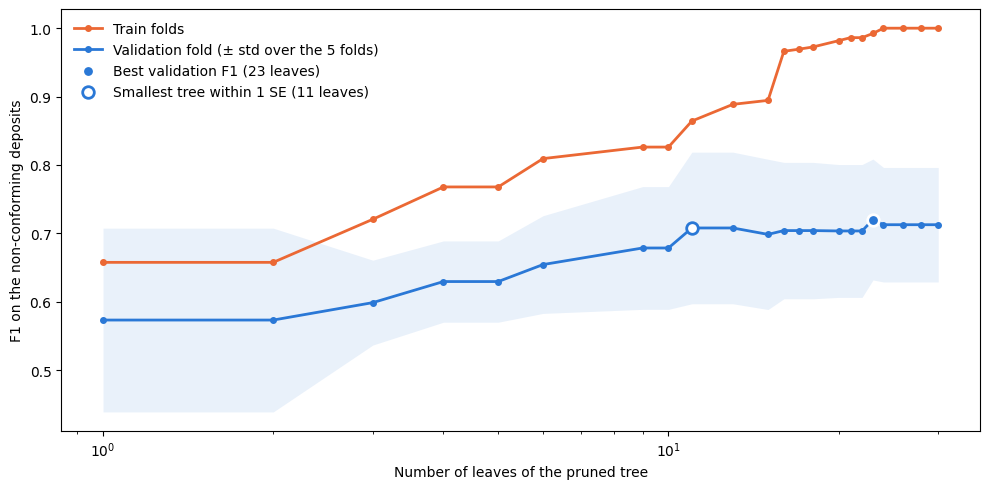

In [6]:
i = search.best_index_
se = path["validation_F1_std"] / np.sqrt(N_FOLDS)
j = path.index[path["validation_F1"] >= path.loc[i, "validation_F1"] - se[i]].max()

fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(leaves, path["validation_F1"] - path["validation_F1_std"], path["validation_F1"] + path["validation_F1_std"], color="#2a78d6", alpha=0.1, linewidth=0)
ax.plot(leaves, path["train_F1"], color="#eb6834", linewidth=2, marker="o", markersize=4, label="Train folds")
ax.plot(leaves, path["validation_F1"], color="#2a78d6", linewidth=2, marker="o", markersize=4, label="Validation fold (± std over the 5 folds)")
ax.scatter(leaves[i], path.loc[i, "validation_F1"], s=70, color="#2a78d6", edgecolor="white", linewidth=2, zorder=3, label=f"Best validation F1 ({leaves[i]} leaves)")
ax.scatter(leaves[j], path.loc[j, "validation_F1"], s=70, color="white", edgecolor="#2a78d6", linewidth=2, zorder=3, label=f"Smallest tree within 1 SE ({leaves[j]} leaves)")
ax.set_xscale("log")
ax.set_xlabel("Number of leaves of the pruned tree")
ax.set_ylabel("F1 on the non-conforming deposits")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

- **Plateau:** The validation F1 rises up to about 11 leaves, then stays between 0.70 and 0.72. The standard deviation over the folds (± 0.09 to 0.11) is much larger than the variations along the plateau.
- **One standard error rule:** As in `1B1`, the smallest tree whose F1 is within one standard error (the standard deviation over the folds divided by $\sqrt{5}$) of the best one. It has 11 leaves, for an F1 of 0.71 against 0.72.

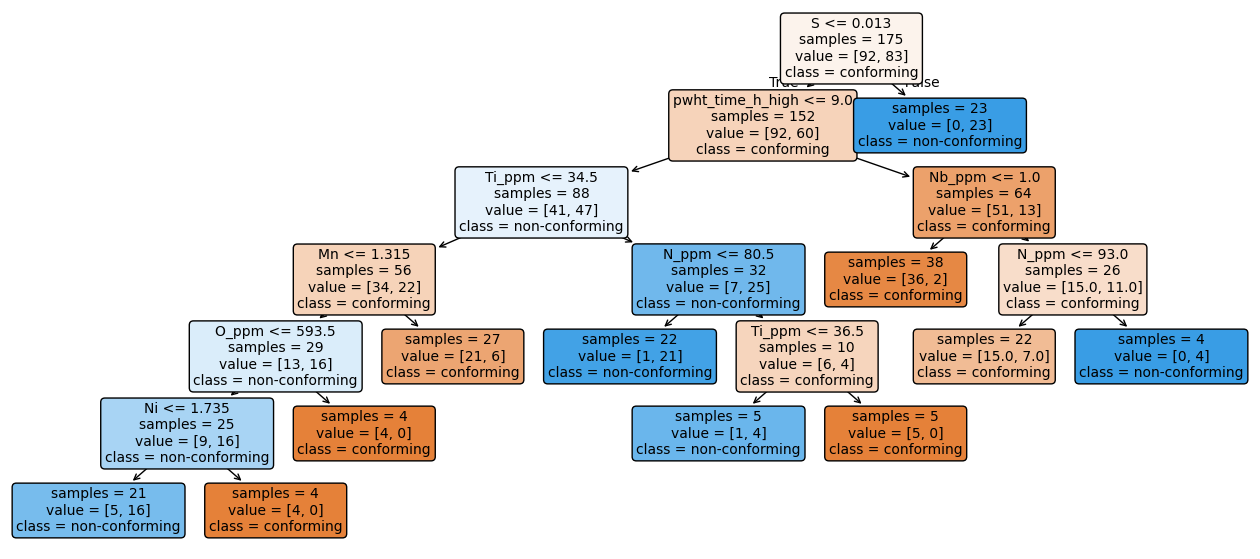

In [7]:
small_tree = DecisionTreeClassifier(random_state=SEED, ccp_alpha=alphas[j]).fit(X, y)

fig, ax = plt.subplots(figsize=(16, 7))
plot_tree(small_tree, feature_names=list(X.columns), class_names=["conforming", "non-conforming"], filled=True, impurity=False, rounded=True, precision=3, fontsize=10, ax=ax)
plt.show()

The 11-leaf tree of the one standard error rule, fitted on the 175 deposits without the `StandardScaler`, so that the thresholds are in the units of the inputs. Each box gives the split, the number of deposits and their number per class (`value = [conforming, non-conforming]`), in orange when most deposits are conforming and in blue when most are non-conforming.

- **S > 0.013:** The 23 deposits with the most sulphur are all non-conforming: the tandem submerged arc deposits of `Pat-1981`, the submerged arc deposits of `Kluket-CuMnB`, `SurianEtAl-C` and `Mart-G`. They mostly fail the UTS and Charpy criteria. The split recognises these papers more than an effect of the sulphur itself.
- **pwht_time_h_high > 9:** The deposits whose hottest heat treatment is the 250 °C hydrogen removal treatment (14 h), so never stress relieved, or the 690 °C treatment of 6 CrMo2 deposits (10 h). 51 of these 64 deposits are conforming, and 36 of the 38 without Nb.
- **pwht_time_h_high ≤ 9:** Mostly the deposits stress relieved at 580 °C for 2 h (70 of the 88), 47 of which are non-conforming. They fail on the yield strength or the UTS, mostly on their rows tested after the stress relief: the stress relief softens the weld below the minimums of 420 MPa and 500 MPa. Among the deposits with little Ti, those with more than 1.3% Mn, the main hardening element of the C-Mn welds, stay above them (21 conforming out of 27).
- **Ti, N, O, Ni, Nb:** The other splits separate the Evans series that vary these elements (`Evans-Al`, `Evans-Ti`, `Evans-V`...), with 4 to 22 deposits per leaf: they describe these studies rather than general rules.

In [8]:
best = search.best_estimator_

tree = evaluate_label("Pruned tree classifier", best, train)
display(tree.dropna(axis=1, how="all").round(2))

oof = oof_predict_label(best, train)
pd.DataFrame(confusion_matrix(y, oof["pred_nc"]), index=["conforming", "non-conforming"], columns=["predicted conforming", "predicted non-conforming"])

,model,target,family,n_clf,n_nc,F1_nc,recall_nc,accuracy,precision_good
0,Pruned tree classifier,label,all,175,83,0.72,0.71,0.74,0.75
1,Pruned tree classifier,label,C-Mn,161,79,0.74,0.73,0.75,0.75
2,Pruned tree classifier,label,CrMo2,8,1,0.00,0.00,0.88,0.88
3,Pruned tree classifier,label,CrMo91,6,3,0.40,0.33,0.50,0.50


,predicted conforming,predicted non-conforming
conforming,71,21
non-conforming,24,59


- **All deposits:** F1 of 0.72 and recall of 0.71 with the 23-leaf tree: 59 of the 83 non-conforming deposits are caught, for 21 false alarms out of 92 conforming deposits (a precision of 0.74).
- **Per family:** The non-conforming CrMo2 deposit is missed, and 1 of the 3 non-conforming CrMo91 deposits is caught.

In [9]:
nested_pred, nested_params = nested_oof_predict_label(search, train)

print("Nested F1:", round(f1_score(y, nested_pred), 3), "| recall:", round(recall_score(y, nested_pred), 3))
nested_params.round(4)

Nested F1: 0.701 | recall: 0.663


,ccp_alpha
fold,
0,0.0000
1,0.0089
2,0.0176
3,0.0148
4,0.0351


The same nested cross-validation as in the other notebooks: the grid search over the 22 values of α is redone for each fold on the 4 other folds only.

- **Nested F1:** 0.70 and recall of 0.66, against 0.72 and 0.71. The chosen α goes from 0 (the full tree) to 0.035 (3 leaves) from one fold to the other: on 4 folds the plateau is flat and the best α moves a lot. As the full tree is almost as good as the best one, the F1 only loses 0.02.

In [10]:
results = save_results(tree)

models = ["Baseline (mean)", "Pruned CART", "Bagging", "Random forest", "Extra-Trees", "Naive Bayes classifier", "k-NN classifier", "SVM classifier", "Pruned tree classifier"]
label = results[(results["target"] == "label") & results["model"].isin(models)]
label.pivot(index="model", columns="family", values=["F1_nc", "recall_nc", "accuracy", "precision_good"]).reindex(index=models).reindex(columns=["all", "C-Mn", "CrMo2", "CrMo91"], level="family").round(2)

F1_nc                    recall_nc                     \
family                   all  C-Mn CrMo2 CrMo91       all  C-Mn CrMo2 CrMo91   
model                                                                          
Baseline (mean)         0.00  0.00  0.00   0.00      0.00  0.00   0.0   0.00   
Pruned CART             0.77  0.78  1.00   0.00      0.81  0.84   1.0   0.00   
Bagging                 0.81  0.83  0.00   0.50      0.72  0.75   0.0   0.33   
Random forest           0.76  0.77  0.00   0.50      0.64  0.66   0.0   0.33   
Extra-Trees             0.84  0.85  0.00   0.80      0.72  0.73   0.0   0.67   
Naive Bayes classifier  0.70  0.71  0.00   0.50      0.69  0.70   0.0   0.67   
k-NN classifier         0.80  0.81  1.00   0.50      0.82  0.82   1.0   0.67   
SVM classifier          0.84  0.85  0.67   0.67      0.83  0.84   1.0   0.67   
Pruned tree classifier  0.72  0.74  0.00   0.40      0.71  0.73   0.0   0.33   

                       accuracy                    precision_good              \
family                      all  C-Mn CrMo2 CrMo91            all  C-Mn CrMo2   
model                                                                           
Baseline (mean)            0.53  0.51  0.88   0.50           0.53  0.51  0.88   
Pruned CART                0.77  0.77  1.00   0.33           0.81  0.82  1.00   
Bagging                    0.84  0.84  0.88   0.67           0.79  0.79  0.88   
Random forest              0.81  0.81  0.88   0.67           0.75  0.74  0.88   
Extra-Trees                0.87  0.87  0.88   0.83           0.80  0.80  0.88   
Naive Bayes classifier     0.72  0.73  0.88   0.33           0.73  0.72  0.88   
k-NN classifier            0.81  0.81  1.00   0.33           0.83  0.82  1.00   
SVM classifier             0.85  0.86  0.88   0.67           0.85  0.85  1.00   
Pruned tree classifier     0.74  0.75  0.88   0.50           0.75  0.75  0.88   

                               
family                 CrMo91  
model                          
Baseline (mean)          0.50  
Pruned CART              0.40  
Bagging                  0.60  
Random forest            0.60  
Extra-Trees              0.75  
Naive Bayes classifier   0.00  
k-NN classifier          0.00  
SVM classifier           0.67  
Pruned tree classifier   0.50

The classification tree is the weakest direct classifier after the naive Bayes, and below the four pruned regression trees of `1B1` with their thresholds (`Pruned CART`, F1 of 0.77 and recall of 0.81). The 175 labelled deposits are too few for a single tree, whereas each regression tree learns from 558 to 723 rows, including the deposits whose label is unknown. Its interest is the readability of its first splits.